In [3]:
import pandas as pd
import numpy as np

RAW_PATH = "house_Prediction.csv" 

COLUMN_NAMES = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
]

MISSING_PLACEHOLDERS = ["", " ", "NA", "N/A", "na", "n/a", "null",
                         "NULL", "?", "-", "--", "None", "none", "nan"]

df = pd.read_csv(
    RAW_PATH,
    sep=r"\s+",
    header=None,
    names=COLUMN_NAMES,
    engine="python",
    na_values=MISSING_PLACEHOLDERS,
    skip_blank_lines=True,
)

print(f"Shape: {df.shape}")
df.head()

Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.describe()

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Duplicate rows: 0


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [5]:
df.columns = [c.strip().upper() for c in df.columns]

obj_cols = df.select_dtypes(include="object").columns.tolist()
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()

print(f"Text columns standardized: {obj_cols or 'none'}")

Text columns standardized: none


In [6]:
for col in df.columns:
    n_missing = df[col].isna().sum()
    if n_missing == 0:
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed '{col}' ({n_missing} missing) with median = {median_val:.3f}")
    else:
        mode_val = df[col].mode(dropna=True)
        mode_val = mode_val.iloc[0] if not mode_val.empty else "Unknown"
        df[col] = df[col].fillna(mode_val)
        print(f"Imputed '{col}' ({n_missing} missing) with mode = '{mode_val}'")

print(f"\nRemaining missing values: {df.isna().sum().sum()}")


Remaining missing values: 0


In [7]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - df.shape[0]} duplicate rows. New shape: {df.shape}")

Removed 0 duplicate rows. New shape: (506, 14)


In [8]:
# Binary indicator column
df["CHAS"] = pd.to_numeric(df["CHAS"], errors="coerce").round().astype("Int64")
bad_chas = ~df["CHAS"].isin([0, 1])
print(f"CHAS values outside {{0,1}}: {bad_chas.sum()}")

# Discrete index column
df["RAD"] = pd.to_numeric(df["RAD"], errors="coerce")
print(f"RAD non-integer values: {(df['RAD'] % 1 != 0).sum()}")

# Force every other column to numeric, catching stray text/format issues
for col in df.columns:
    if col == "CHAS":
        continue
    coerced = pd.to_numeric(df[col], errors="coerce")
    newly_invalid = coerced.isna().sum() - df[col].isna().sum()
    if newly_invalid > 0:
        print(f"'{col}': {newly_invalid} non-numeric entries coerced to NaN")
    df[col] = coerced

# Fill any NaNs introduced by coercion
for col in df.columns[df.isna().any()]:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f"Post-standardization fill: '{col}' -> median {med:.3f}")

CHAS values outside {0,1}: 0
RAD non-integer values: 0


In [9]:
print(f"Final shape: {df.shape}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

df.to_csv("cleaned_house_data.csv", index=False)
df.head()

Final shape: (506, 14)
Missing values: 0
Duplicate rows: 0


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("cleaned_house_data.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [11]:
summary = pd.DataFrame({
    "mean": df.mean(numeric_only=True),
    "median": df.median(numeric_only=True),
    "mode": df.mode(numeric_only=True).iloc[0],
    "std": df.std(numeric_only=True),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True),
})
summary

,mean,median,mode,std,min,max
CRIM,3.613524,0.25651,0.01501,8.601545,0.00632,88.9762
ZN,11.363636,0.00000,0.00000,23.322453,0.00000,100.0000
INDUS,11.136779,9.69000,18.10000,6.860353,0.46000,27.7400
CHAS,0.069170,0.00000,0.00000,0.253994,0.00000,1.0000
NOX,0.554695,0.53800,0.53800,0.115878,0.38500,0.8710
RM,6.284634,6.20850,5.71300,0.702617,3.56100,8.7800
AGE,68.574901,77.50000,100.00000,28.148861,2.90000,100.0000
DIS,3.795043,3.20745,3.49520,2.105710,1.12960,12.1265
RAD,9.549407,5.00000,24.00000,8.707259,1.00000,24.0000
TAX,408.237154,330.00000,666.00000,168.537116,187.00000,711.0000


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


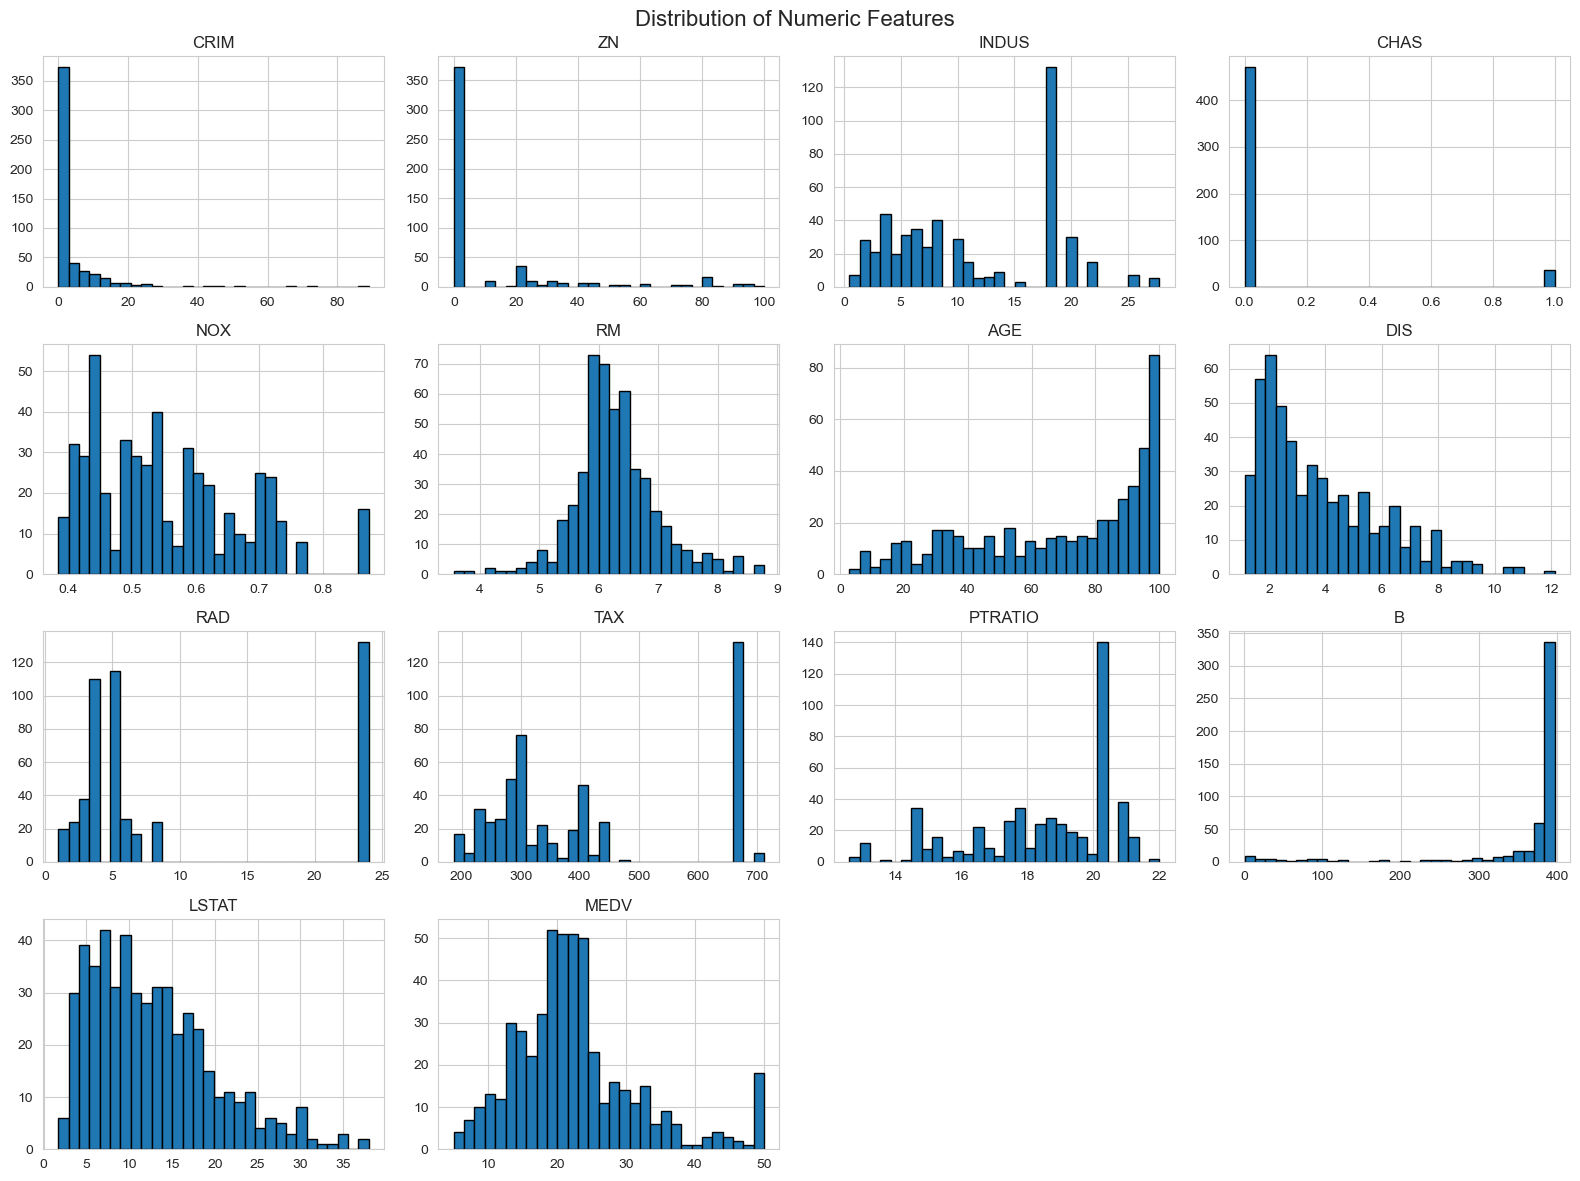

In [13]:
df.hist(figsize=(16, 12), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

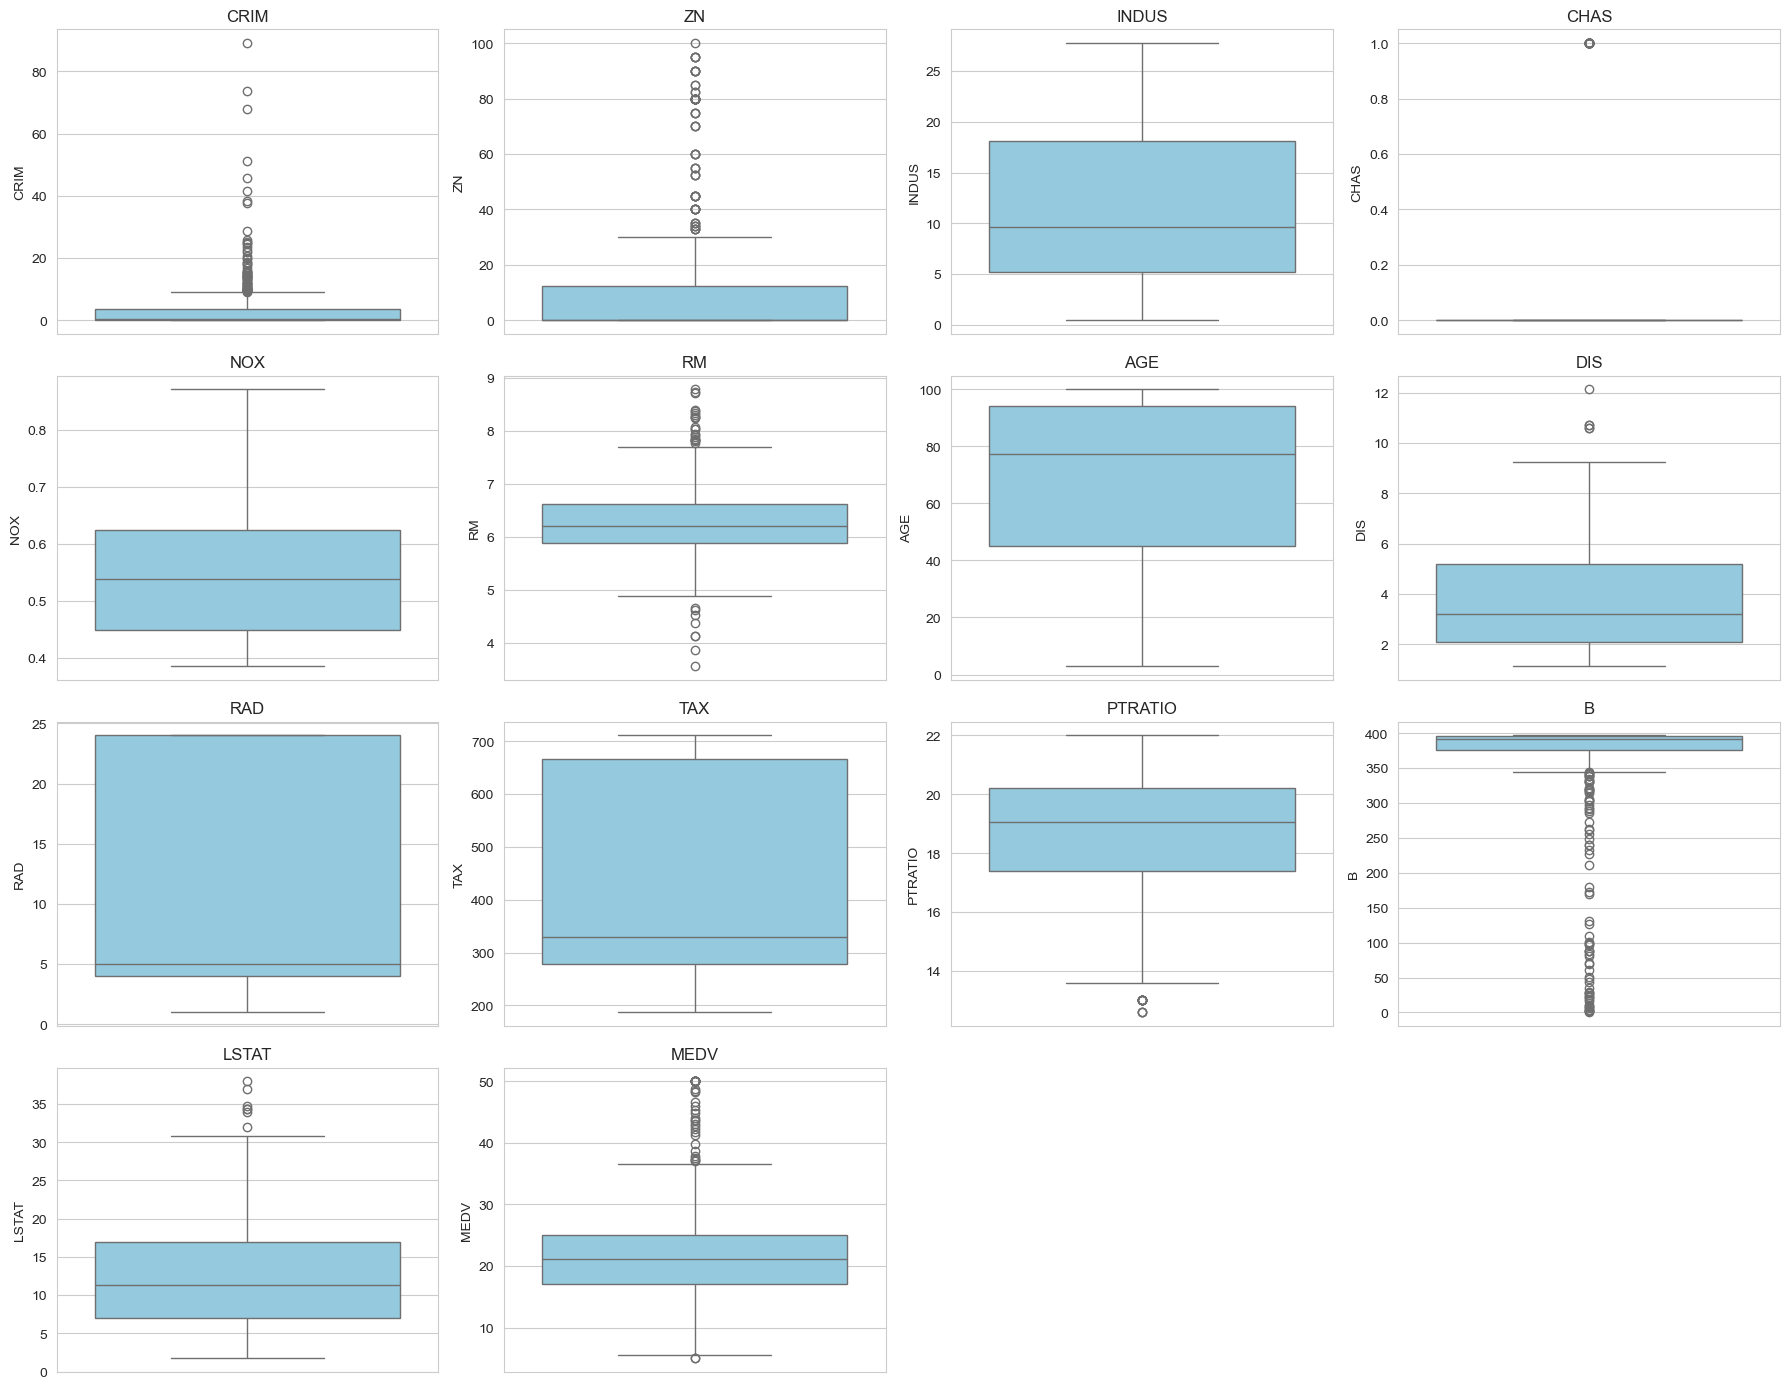

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)

# hide unused subplots
for j in range(len(df.columns), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

C:\Users\FBDA22-007\AppData\Local\Temp\ipykernel_28208\3319965751.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="CHAS", y="MEDV", data=df, palette="Set2")


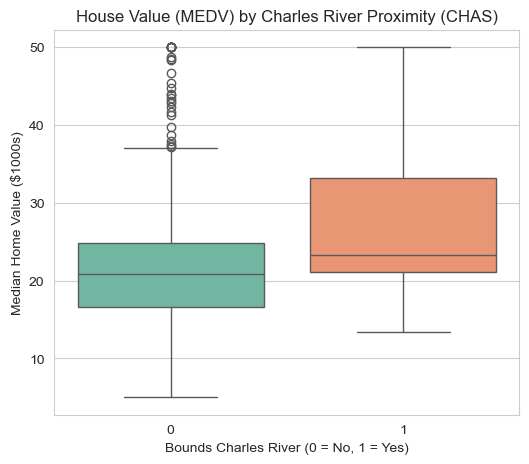

In [15]:
plt.figure(figsize=(6, 5))
sns.boxplot(x="CHAS", y="MEDV", data=df, palette="Set2")
plt.title("House Value (MEDV) by Charles River Proximity (CHAS)")
plt.xlabel("Bounds Charles River (0 = No, 1 = Yes)")
plt.ylabel("Median Home Value ($1000s)")
plt.show()

In [16]:
corr = df.corr(numeric_only=True)
corr.round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.00,-0.20,0.41,-0.06,0.42,-0.22,0.35,-0.38,0.63,0.58,0.29,-0.39,0.46,-0.39
ZN,-0.20,1.00,-0.53,-0.04,-0.52,0.31,-0.57,0.66,-0.31,-0.31,-0.39,0.18,-0.41,0.36
INDUS,0.41,-0.53,1.00,0.06,0.76,-0.39,0.64,-0.71,0.60,0.72,0.38,-0.36,0.60,-0.48
CHAS,-0.06,-0.04,0.06,1.00,0.09,0.09,0.09,-0.10,-0.01,-0.04,-0.12,0.05,-0.05,0.18
NOX,0.42,-0.52,0.76,0.09,1.00,-0.30,0.73,-0.77,0.61,0.67,0.19,-0.38,0.59,-0.43
RM,-0.22,0.31,-0.39,0.09,-0.30,1.00,-0.24,0.21,-0.21,-0.29,-0.36,0.13,-0.61,0.70
AGE,0.35,-0.57,0.64,0.09,0.73,-0.24,1.00,-0.75,0.46,0.51,0.26,-0.27,0.60,-0.38
DIS,-0.38,0.66,-0.71,-0.10,-0.77,0.21,-0.75,1.00,-0.49,-0.53,-0.23,0.29,-0.50,0.25
RAD,0.63,-0.31,0.60,-0.01,0.61,-0.21,0.46,-0.49,1.00,0.91,0.46,-0.44,0.49,-0.38
TAX,0.58,-0.31,0.72,-0.04,0.67,-0.29,0.51,-0.53,0.91,1.00,0.46,-0.44,0.54,-0.47


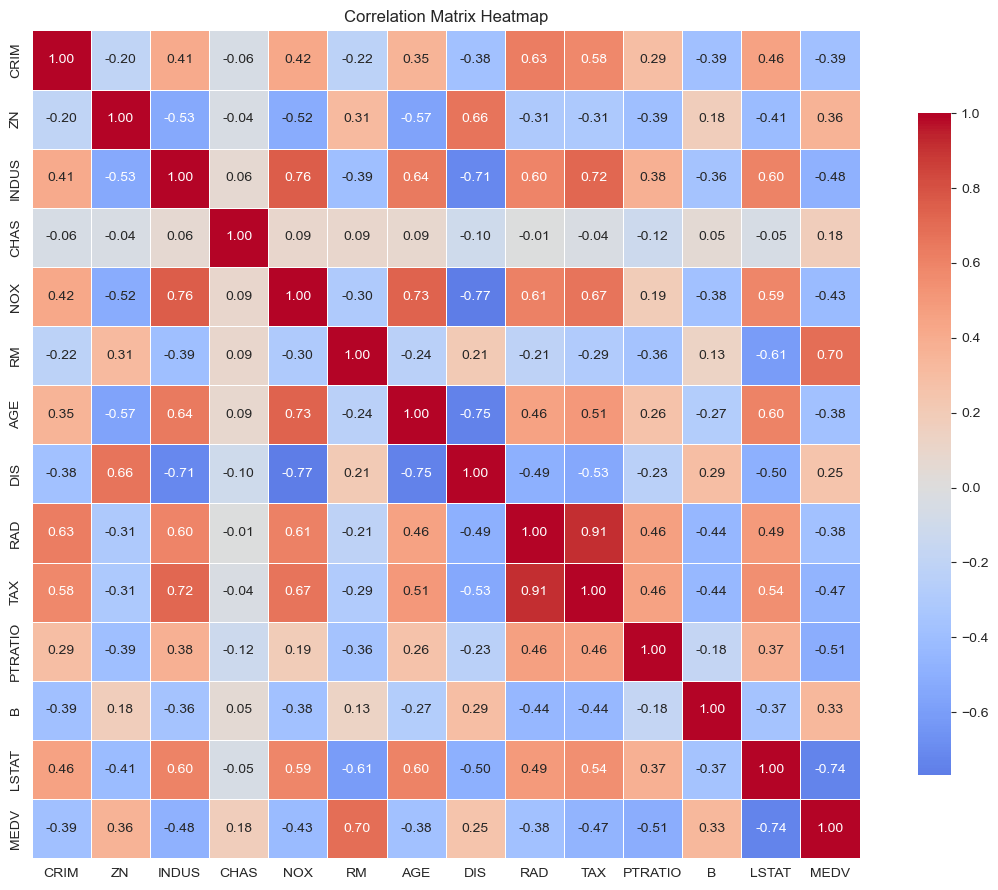

In [17]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

Correlation with MEDV (sorted by strength):
LSTAT     -0.737663
RM         0.695360
PTRATIO   -0.507787
INDUS     -0.483725
TAX       -0.468536
NOX       -0.427321
CRIM      -0.388305
RAD       -0.381626
AGE       -0.376955
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
Name: MEDV, dtype: float64


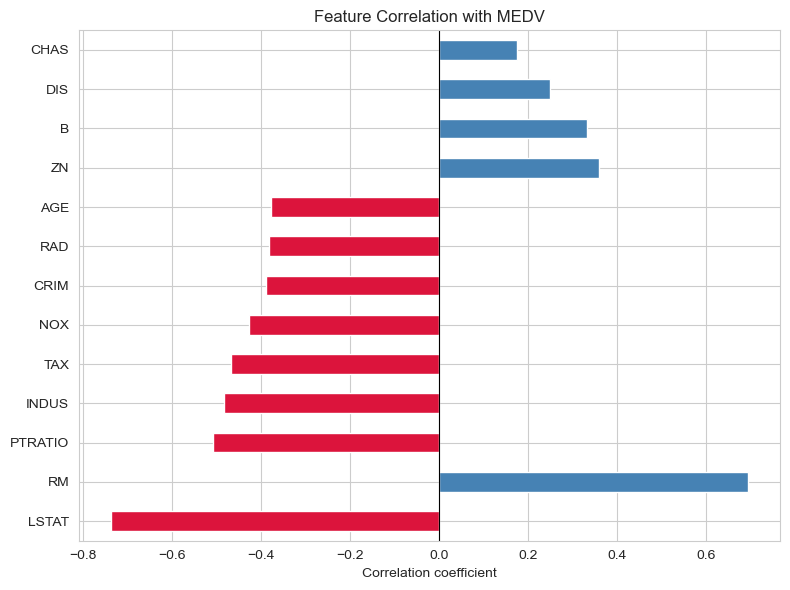

In [18]:
target_corr = corr["MEDV"].drop("MEDV").sort_values(key=abs, ascending=False)
print("Correlation with MEDV (sorted by strength):")
print(target_corr)

plt.figure(figsize=(8, 6))
target_corr.plot(kind="barh", color=target_corr.apply(lambda x: "crimson" if x < 0 else "steelblue"))
plt.title("Feature Correlation with MEDV")
plt.xlabel("Correlation coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

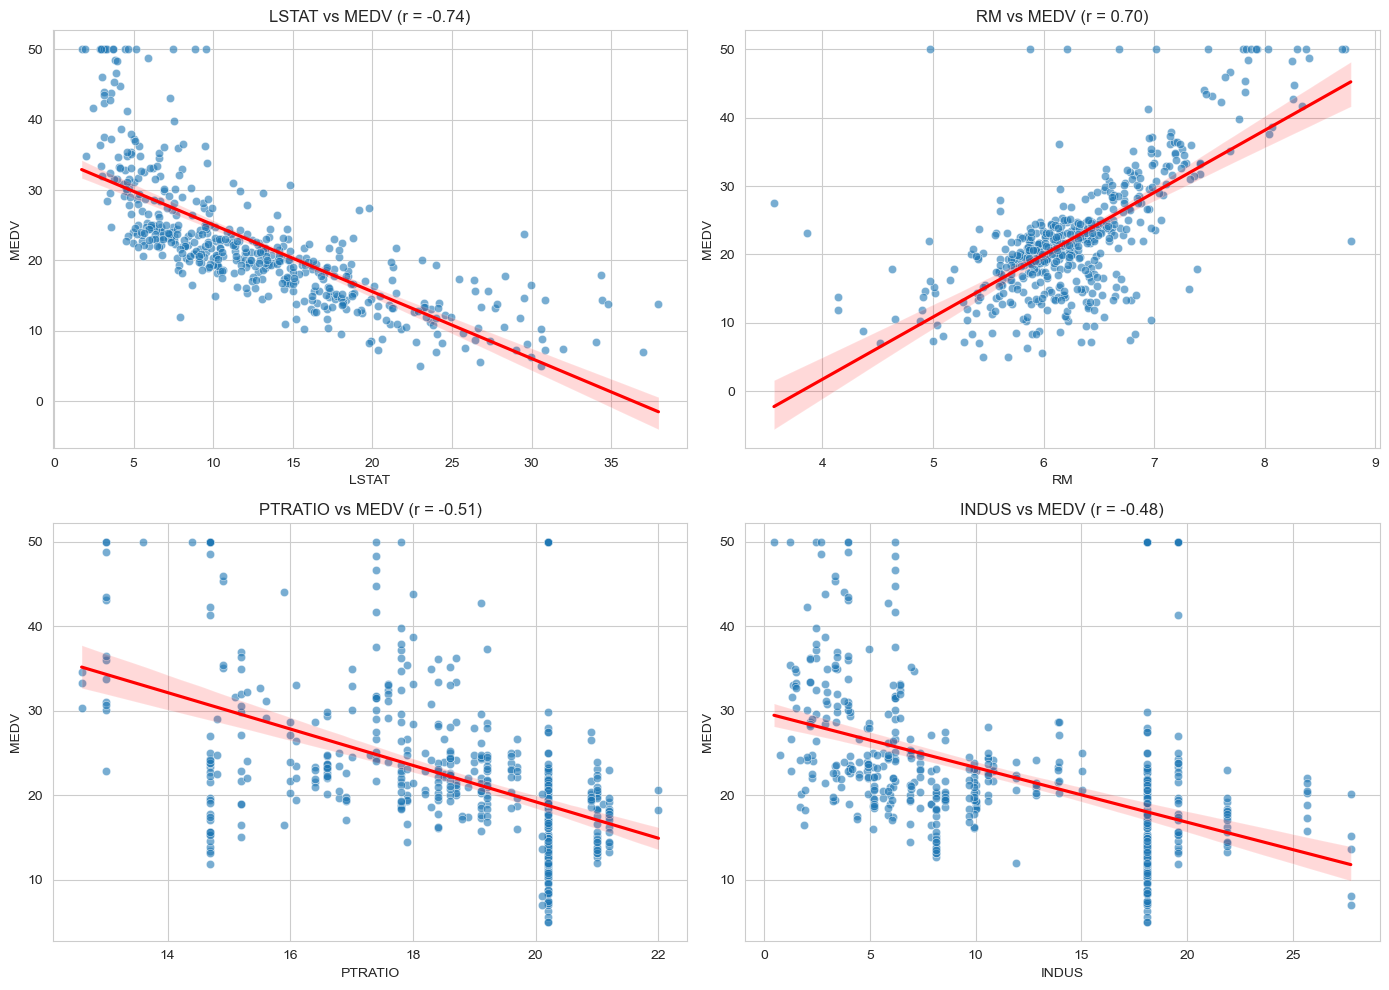

In [19]:
top_features = target_corr.abs().sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.scatterplot(x=df[feat], y=df["MEDV"], ax=axes[i], alpha=0.6)
    sns.regplot(x=df[feat], y=df["MEDV"], ax=axes[i], scatter=False, color="red")
    axes[i].set_title(f"{feat} vs MEDV (r = {corr.loc[feat, 'MEDV']:.2f})")

plt.tight_layout()
plt.show()

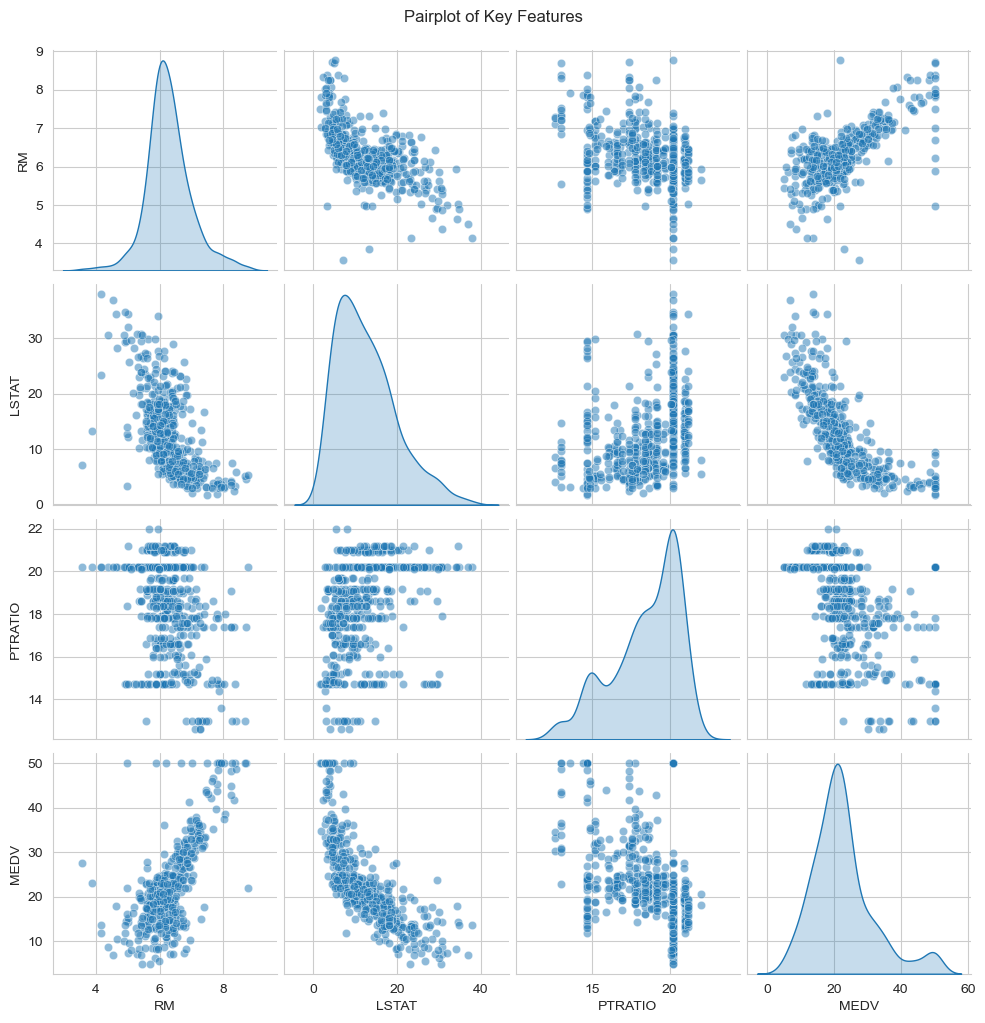

In [20]:
key_cols = ["RM", "LSTAT", "PTRATIO", "MEDV"]
sns.pairplot(df[key_cols], diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()